# Single-cell multiomics

This lab analyses a single-cell multiomic dataset (ATAC-seq + RNA-seq), collected from human bone marrow cells, which has been pre-processed with 10X's default CellRanger ARC software and ArchR for the ATAC-seq component. In general, the pre-processing of such data is very similar to the per-modality-specific pipelines from the previous labs, with some exceptions: most notably, cell filtering typically depends on a combination of QC parameters from each technology.

To store multiome data, we can use the Python package [mudata](https://mudata.readthedocs.io/stable/) to synchronize changes across individual modalities and collect joint information, for example. Remember, [anndata](https://anndata.readthedocs.io/en/latest/) aligns different data views along observations and variables; mudata adds an additional dimension on top of that as our modalities align along the observations. There are tools merging the different modalities but it is important to remember that such an approach can easily obscure differences between the modalities that are oftentimes the most interesting. As such, we will look at RNA- and ATAC-specific representations and embeddings here.

The dataset for this lab is pre-filtered and only includes the information relevant for our purposes to keep things simple. Specifically, the important metadata:

RNA-specific
* total_counts: the library size of the cell

ATAC-specific
* n_fragments: the number of fragments per cell
* frip: the cell-specific FRiP score
* sequence: the DNA sequence corresponding to the peak
* dist_to_tss: the distance to the nearest transcription start site (TSS)
* nearest_gene: the nearest gene
* peak_type: the type of peak (Distal, Exonic, Intronic, Promoter)

Shared
* metacell: the metcall the cell is assigned to
* celltype: the celltype label

## Setup instructions

You can either use the `DATA_DIR` variable to import the data from *data/lab_4/processed/*, or copy the data relevant for this lab into your repositories data directory with

```bash
cp -r /athena/qibs_class/scratch/pfw4001/data/lab_4 /athena/qibs_class/scratch/CWID/qibs2026/data/
```

and import from there.

## Library imports

In [1]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray

import matplotlib.pyplot as plt
import seaborn as sns

import mudata as md
import scanpy as sc

from qibs2026 import DATA_DIR

## General settings

In [2]:
# Set behavior of .update() to default behavior of mudata>=0.4
md.set_options(pull_on_update=False)

In [3]:
sc.settings.verbosity = 2
sc.set_figure_params(frameon=False, transparent=True)

## Constants

In [4]:
DATASET_ID = "lab_4"
data_path = "/athena/qibs_class/scratch/jfm4002/qibs2026/data/lab_4/processed/"

## Function definitions

## 1. Data loading

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  Use <i>mudata</i> to load the H5MU file <i>mdata.h5mu</i> from <i>data/lab_4/processed/</i>.
</div>

In [5]:
# Implement your solution here
mdata = md.read_h5mu(f"{data_path}/mdata.h5mu")
mdata

MuData object with n_obs × n_vars = 6881 × 258255
  obs:	'sample', 'celltype', 'metacell'
  var:	'start', 'end', 'seqnames'
  uns:	'celltype_colors', 'sample_colors'
  2 modalities
    rna:	6881 x 12142
      obs:	'sample', 'celltype', 'metacell', 'total_counts'
      var:	'start', 'end', 'seqnames'
      uns:	'celltype_colors', 'neighbors', 'sample_colors', 'umap'
      obsm:	'X_umap'
      obsp:	'connectivities', 'distances'
    atac:	6881 x 246113
      obs:	'sample', 'celltype', 'metacell', 'n_fragments', 'frip'
      var:	'start', 'end', 'seqnames', 'sequence', 'dist_to_tss', 'nearest_gene', 'peak_type'
      uns:	'celltype_colors', 'neighbors', 'sample_colors', 'umap'
      obsm:	'X_umap', 'gene_scores'
      obsp:	'connectivities', 'distances'

## 2. Data preprocessing

The data has already been processed and for our purposes redundant information has been removed. However, these additional quality metrics are the same we already saw in the previous labs, i.e., results from standard scanpy and ArchR workflows; there are no quality parameters unique to multiome data. Some but not all modality-specific parameters correlate, so filtering is more involved compared to the unimodal setting. To minimize the loss of nuanced information, like rare populations, we associate an unfiltered expression matrich with a tile matrix with barcodes having very few counts; running ArchR with very liberal parameters will yield the latter. As we aim for cells of high quality in both modalities, filtering will involve QC parameters from both modalities to remove poor observations of low quality in either technology.

To start with, we will briefly how library size, number of fragments, and FRiP scores relate to each other at the cellular level.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  <ol type="a">
    <li>Plot each cell's library size against its number of fragments, both on a log1p scale.</li>
    <li>Plot each cell's log1p-transformed library size against its FRiP score, both on a log1p scale.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.1</b>
  </div>
  What is the Spearman correlation between the number of transcripts and fragments per cell captured? Round to four decimals.
</div>

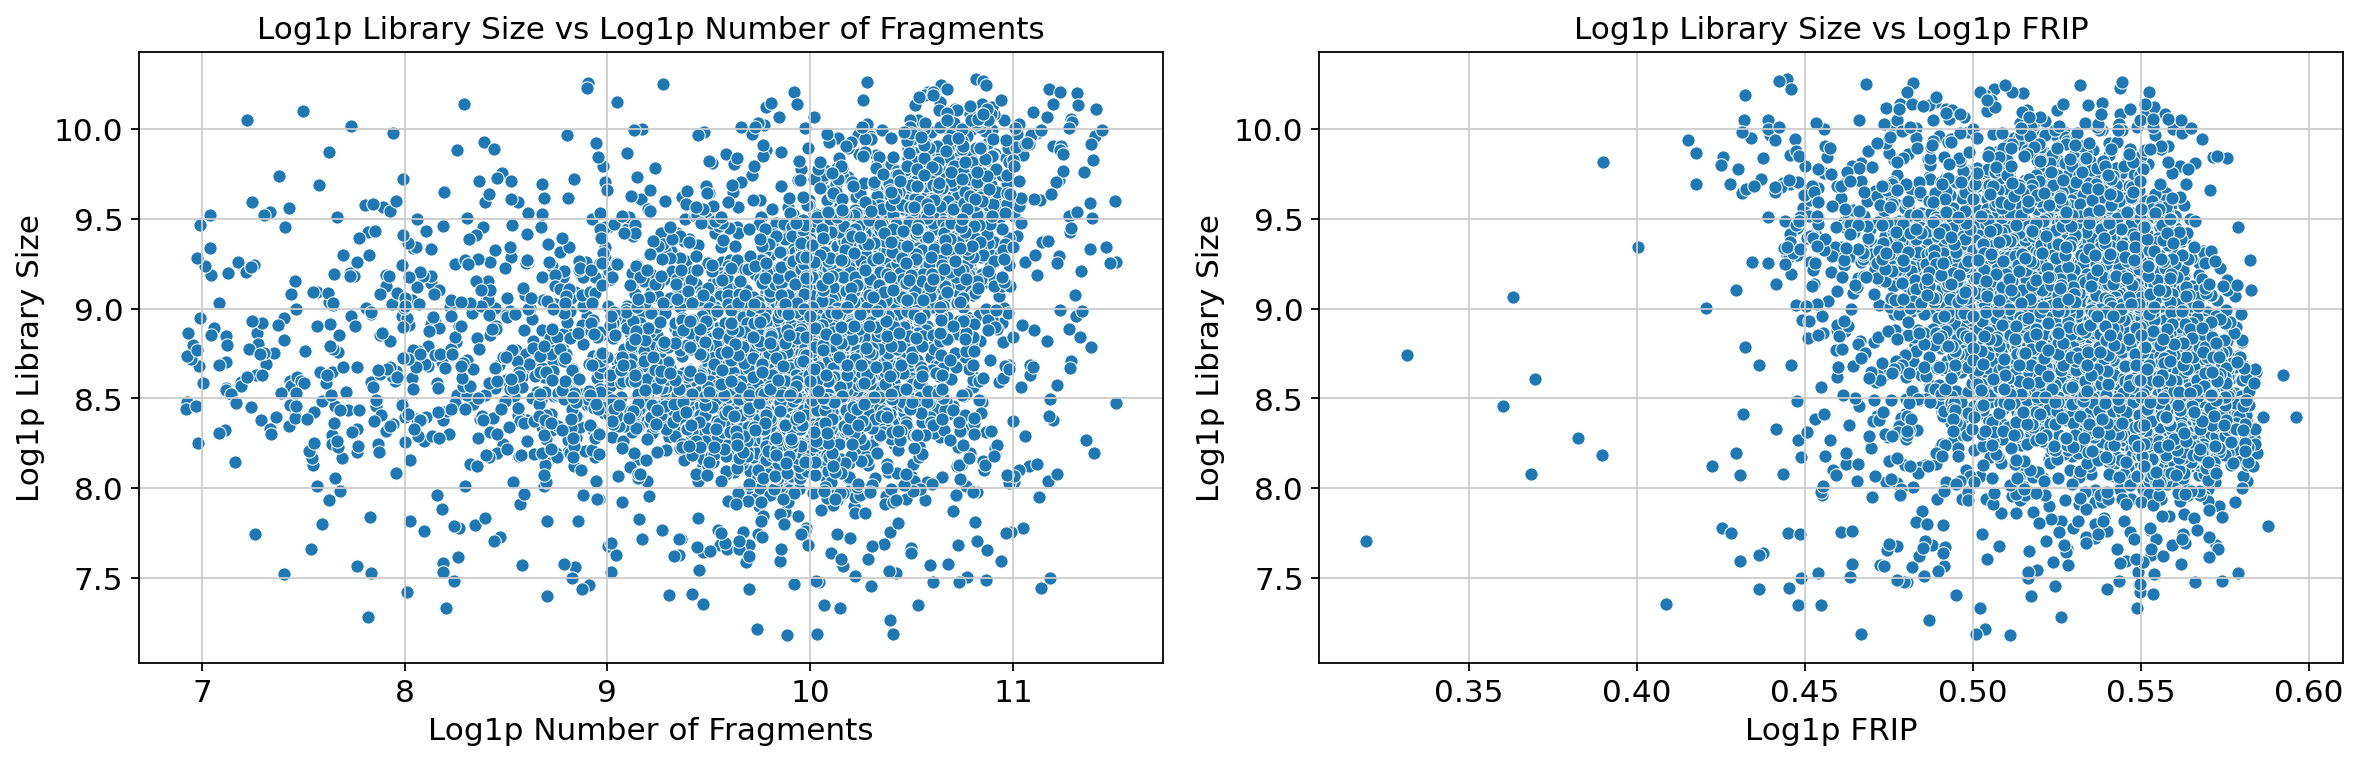

In [6]:
# Implement your solution here
log1p_library_size = np.log1p(mdata['rna'].obs['total_counts'])
log1p_n_fragments = np.log1p(mdata['atac'].obs['n_fragments'])
log1p_frip = np.log1p(mdata['atac'].obs['frip'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(y=log1p_library_size, x=log1p_n_fragments, ax=axes[0])
axes[0].set_ylabel('Log1p Library Size')
axes[0].set_xlabel('Log1p Number of Fragments')
axes[0].set_title('Log1p Library Size vs Log1p Number of Fragments')
sns.scatterplot(y=log1p_library_size, x=log1p_frip, ax=axes[1])
axes[1].set_ylabel('Log1p Library Size')
axes[1].set_xlabel('Log1p FRIP')
axes[1].set_title('Log1p Library Size vs Log1p FRIP')
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import spearmanr
spearman_transcripts_fragments = spearmanr(mdata["rna"].obs['total_counts'], mdata["atac"].obs['n_fragments'])
print(f"Spearman correlation between total counts and number of fragments: {spearman_transcripts_fragments.correlation:.4f}")

Spearman correlation between total counts and number of fragments: 0.3878


There are tools for constructing so-called joint embeddings that integrate the information from both modalities. While these embeddings have their benefits, modality-specific embeddings allow comparing and contrasting the different data views. Below's UMAP representation highlight that the information content conveyed by the transcriptomic and epigenomic views of the cells generally agree, these embeddings also suggest that there are subtle differences.

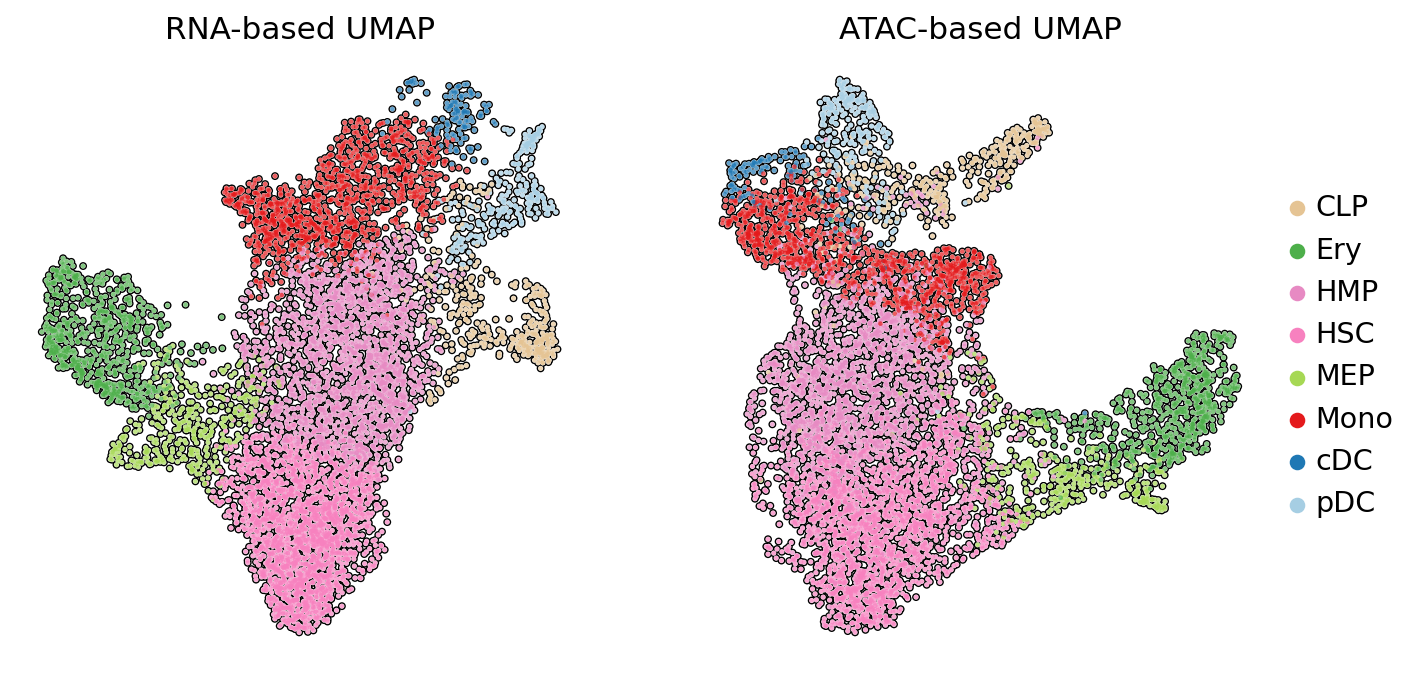

<Figure size 320x320 with 0 Axes>

In [8]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
sc.pl.embedding(
    mdata["rna"],
    basis="umap",
    color="celltype",
    add_outline=1,
    legend_loc=None,
    title="RNA-based UMAP",
    show=False,
    ax=ax[0],
)
sc.pl.embedding(mdata["atac"], basis="umap", color="celltype", add_outline=1, title="ATAC-based UMAP", ax=ax[1])
plt.tight_layout()
plt.show()

## 3. Gene-peak correlations

A major goal, and in fact a major motivation for developing multiomal assays, is understanding gene regulatory relationships: how does accessibility relate to transcription and vice versa to orchestrate cellular identity and change? At the most basic level, this question boils down to quantifying how accessibility correlates with gene expression (GEX) - a question we can answer by employing a two-step process with an optional third follow-up:

<ol type="i">
  <li>Identify candidate cis-regulatory elements (CREs) associated with each gene, including promoters and more distal enhancers that may contain binding domains which actively regulate the expression of nearby genes.</li>
  <li>Quantify the relationship between accessibility in CREs and GEX across cells.</li>
  <li>Link the putative CREs to potential <i>trans</i> factors, i.e., transcription factors (TFs), wich may regulate them.</li>
</ol>

Note that because we have paired information - the transcriptomic view from scRNA-seq, and the accessibility view from scATAC-seq for one and the same single cell - we can build models which directly try to predict how variability in the former influences the latter as cells undergo some process, like differentiation in the bone marrow in our example. Additionally, matching CREs with TFs is essential for identifying potential mechanisms of gene regulation: the proteins which may bind in CREs linked to gene expression are often the effector proteins which orchestrate the regulatory process.

### Identifying potential enhancers and promoters

Identifying CREs amounts to linking the peaks in our dataset, which represent potential enhancers and promoters, to their putative target genes. For multiome data alone, the general rule of thumb is to map peaks to their targets based on the nearest TSS.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.1</b>
  </div>
  <ol type="a">
    <li>What is the median distance between a peak and its nearest TSS?</li>
    <li>What is the furthest distance between a peak and its nearest TSS?</li>
    <li>What is the unit of these distances?</li>
  </ol>
</div>

In [9]:
# Implement your solution here
print(f"Median distance between a peak and its nearest TSS is: {mdata['atac'].var['dist_to_tss'].median()} bp")
print(f"The furthest distance between a peak and its nearest TSS is: {mdata['atac'].var['dist_to_tss'].max()} bp")

Median distance between a peak and its nearest TSS is: 6346.0 bp
The furthest distance between a peak and its nearest TSS is: 1107269 bp


The distribution of these distances have a wide range, but a subset of peaks is almost aways mapped correctly to their corresponding gene: peaks withing ~500bp, but not within the gene body (considered as promoters) and peaks within gene bodies (exonic of intronic); mapping of enhances is much noisier since they can loop to reach far-away chromatin; i.e., the further away from a TSS, the less confident we can be that an enhancer is really associated with that gene, but the mapping is usually a good approximation within 50 kilobases.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.1</b>
  </div>
  Recover all peak gene pairs, for peaks within 50,000bps of their TSS (<code>peak_gene_pairs</code>) and annotated as a promoter (<code>promoter_gene_pair</code>). Make sure to only include genes that exist in the RNA data. Save the data as <a href="https://pandas.pydata.org/">pandas</a> DataFrames with columns <code>"peak"</code> and <code>"nearest_gene"</code>.
</div>

**Self-check:** There are 16296 promoter-gene pairs.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.2</b>
  </div>
  Among these promoters, what is the average distance to their TSS? Round to the clostest integer.
</div>

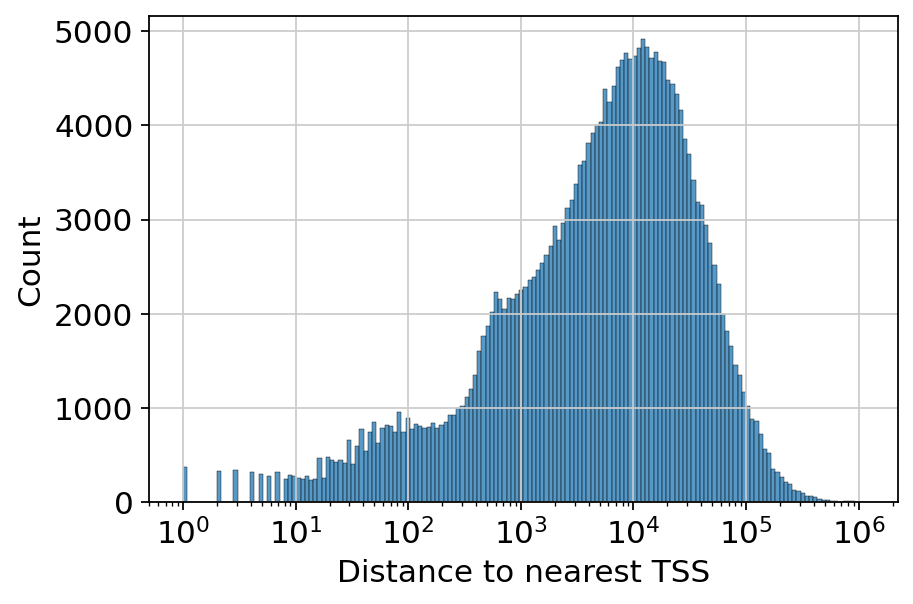

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(mdata["atac"].var["dist_to_tss"], log_scale=True, ax=ax)
ax.set(xlabel="Distance to nearest TSS")
plt.show()

In [11]:
# Implement your solution here
atac_promoters_mask = (mdata["atac"].var["dist_to_tss"] <= 50000) & (mdata["atac"].var["peak_type"] == "Promoter") & (mdata["atac"].var["nearest_gene"].isin(mdata["rna"].var_names))
atac_promoters = mdata["atac"].var[atac_promoters_mask]
promoter_gene_pair = pd.DataFrame({
    "peak": atac_promoters.index,
    "gene": atac_promoters["nearest_gene"].values,
})
print(f"Number of promoter pairs: {len(atac_promoters)}")
print(f"The average distance to TSS among these promoters is {atac_promoters['dist_to_tss'].mean():.2f} bp")

Number of promoter pairs: 16296
The average distance to TSS among these promoters is 440.36 bp


Having these approximate mappings, we can now investigate the between accessibility and GEX. Given that we are most confident in our promoter mapping, we will first focus on those to get a sense of potantial relationships - first at the level at single-cell, then at the level of metacells.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.2</b>
  </div>
  Compute the Pearson correlation <code>corr_sc</code> between the accessibility and gene expression of each promoter-gene pair.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.3</b>
  </div>
  What is the average absolute correlation? Round to 4 decimals.
</div>

In [12]:
# Implement your solution here
from scipy.stats import pearsonr
corr_sr = pearsonr(mdata["atac"][:, promoter_gene_pair["peak"]].X.toarray(), mdata["rna"][:, promoter_gene_pair["gene"]].X.toarray(), axis=0)
print(f"Average absolute Pearson correlation across promoter-gene pairs: {np.mean(np.abs(corr_sr)):.4f}")

Average absolute Pearson correlation across promoter-gene pairs: 0.2360


As you can see, the single-cell level correlation is very low! After all, we know from bulk studies that GEX-accessibility correlation should track with polymerase binding. So, as in our previous lab, we will turn to the metacell-level view to try mitigating sparsity.

In [14]:
pseudobulk_rna = sc.get.aggregate(mdata["rna"], by="metacell", func="mean")
pseudobulk_atac = sc.get.aggregate(mdata["atac"], by="metacell", func="mean")

# Metacells were computed independently for each modality, so align metacell names to use the mudata framework
pseudobulk_atac.obs_names = pseudobulk_rna.obs_names

pseudobulk_mdata = md.MuData({"rna": pseudobulk_rna, "atac": pseudobulk_atac})
del pseudobulk_rna, pseudobulk_atac

for modality in pseudobulk_mdata.mod.keys():
    pseudobulk_mdata[modality].X = pseudobulk_mdata[modality].layers["mean"].copy()
    del pseudobulk_mdata[modality].layers["mean"]
    pseudobulk_mdata[modality].obs = pseudobulk_mdata[modality].obs.drop(columns=["metacell"])

pseudobulk_mdata

MuData object with n_obs × n_vars = 75 × 258255
  2 modalities
    rna:	75 x 12142
      obs:	'n_obs_aggregated'
      var:	'start', 'end', 'seqnames'
    atac:	75 x 246113
      obs:	'n_obs_aggregated'
      var:	'start', 'end', 'seqnames', 'sequence', 'dist_to_tss', 'nearest_gene', 'peak_type'

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.3</b>
  </div>
  Recompute the Pearson correlation between the accessibility and gene expression of each promoter-gene pair at the metacell level (variable name <code>corr_metacell</code>).
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.4</b>
  </div>
  What is the average fold change of the metacell-based correlation compared to the single-cell-based correlation? Round to 4 decimals.
</div>

In [ ]:
# Implement your solution here

In [ ]:
# Fill in the missing code below to plot the single-cell based correlation against the corresponding metacell-based
# statistic
corr_df = pd.DataFrame(
    {
        "corr_sc": [None] * promoter_gene_pair.shape[0],  # Add single-cell-based correlation here
        "corr_metacell": [None] * promoter_gene_pair.shape[0],  # Add metacell-based correlation here
    }
)
corr_df[["peak", "nearest_gene"]] = promoter_gene_pair.values

corr_df = corr_df.nlargest(5, "corr_metacell").reset_index()
fig, ax = plt.subplots(nrows=corr_df.shape[0], ncols=2, figsize=(8, 4 * corr_df.shape[0]))
for row_id, row in corr_df.iterrows():
    ax[row_id, 0].scatter(
        x=mdata["atac"][:, row["peak"]].X.toarray().squeeze(),
        y=mdata["rna"][:, row["nearest_gene"]].X.toarray().squeeze(),
        c="lightblue",
        edgecolor="black",
        linewidth=0.5,
        s=50,
    )
    ax[row_id, 0].set(ylabel=f"{row['nearest_gene']} GEX")

    ax[row_id, 1].scatter(
        x=pseudobulk_mdata["atac"][:, row["peak"]].X,
        y=pseudobulk_mdata["rna"][:, row["nearest_gene"]].X,
        c="purple",
        edgecolor="black",
        linewidth=0.5,
        s=50,
    )

ax[0, 0].set(title="Single-cell level")
ax[0, 1].set(title="Metacell level")
ax[-1, 0].set(xlabel="Accessibility")
ax[-1, 1].set(xlabel="Accessibility")

plt.tight_layout()
plt.show()

As we can see, scATAC-seq data already saw in our previous, scATAC-seq-focused lab. While seeing promoter access tending to correlate with GEX is reassuring, it does not reveal much about our biological system as it does not revel gene-regulatory relationsships.

## 4. Simple models of gene regulation

It turns out that enhancers tend to be much more dynamic and variable across cell states than promoters are; it follows that much of the "important" gene regulation will be occurring at these. However, as discussed, enhancers are a trickier to incorporate than promoters: in part because our confidence in each of these CREs being associated with their correct gene is low; gene regulation involving enhancers is a complex process that integrates the binding at multiple CREs to ultimate result in recruitment of the transcriptional machinery to promoters; and, to make matters worse, our so-called enhancers might also include repressive elements, actively interfering with expression.

The "correct" mathematical of this is likely equally complex. That said, especially given the noisy data we have, a simple model will probably work just fine for basic prediciton. For each gene, we can assume that its expression is a weighted sum of accessibility at nearby enhancers and promoters. This allows for negative weights (such that a given "enhancer" might be anti-correlated with its gene) or 0 weights (such that an enhancer, perhaps erroneously mapped, has no impact on that gene's expression).

To build these models, we can use standard linear regression fit on our data. Below we walk through this, as well as some slight variations to try to improve performance.

### Setting up the model fitting

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.1</b>
  </div>
  <ol type="a">
    <li>Use <a href="https://scikit-learn.org/stable/">sklearn</a>'s <code>train_test_split</code> function (<code>random_state=0</code>) to split the metacells into train and test sets; assign 25% of the observations to the test set.</li>
    <li>For the gene MPO, define the variable <code>X_train</code> and <code>Y_train</code> (<code>X_test</code> and <code>Y_test</code>) as our training (test) data and target values, respectively. Remember: we want to build a model of gene-regulation to predict GEX.</li>
  </ol>
</div>

In [ ]:
# Implement your solution here
gene_name = "MPO"

In [ ]:
# Implement your solution here

In the end, we want to compare how different models perform, to which end we define appropriate variables to keep track of each model's relevant output: the model coefficients, its prediction on the train set, and its predicition on the test set.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.2</b>
  </div>
  <ol type="a">
    <li>Define a <a href="https://pandas.pydata.org/">pandas</a> DataFrame <code>regression_coef</code>, indexed by the features of our model, i.e., the peaks associated with MPO.</li>
    <li>Define the data frames <code>train_pred</code> and <code>test_pred</code>, indexed by the corresponding metacell IDs, and add the corresponding ground truth data as a column <code>ground_truth</code>.</li>
  </ol>
</div>

In [ ]:
# Implement your solution here
regression_coef = None

train_pred = None
test_pred = None

### Linear regression

We will use classical linear regression to fit, in a first pass, our data with <a href="https://scikit-learn.org/stable/">sklearn</a>, a well-established tool for predictive data analysis with a consistent API. The main concept relevant for our purpose here are model classes - the core objects for fitting statistical models with sklearn - which help streamline data analysis using the following pipeline:

<ol type="i">
  <li>As a first step, we fit the model to our training data, using the <code>.fit</code> method that automatically adds the fitted and any additionally relevant parameters to the model class; for our examples here, <code>coef_</code> is the corresponding attribute.</li>
  <li>Following, to apply our fitted model to new data, we generally transform the new data to make it comparable to the training data. To this end, each model class provides the <code>.transform</code> method. Note that this step is not needed in our use case.</li>
  <li>Finally, calling the <code>.predict</code> method provides us with the prediction.</li>
</ol>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.3</b>
  </div>
  <ol type="a">
    <li>Use <a href="https://scikit-learn.org/stable/">sklearn</a> to fit a linear regression model and save the results in the appropriate data frames (column name <code>linear</code>), prepared in Exercise 4.2.</li>
    <li>Compute the Pearson correlation between ground truth and prediction on both train and test set. Save them in the variables <code>train_corr</code> and <code>test_corr</code>, respectively.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.1</b>
  </div>
  <ol type="a">
    <li>What is the Pearson correlation between ground truth and predicted GEX on the train data? Round to 2 decimals.</li>
    <li>What is the Pearson correlation between ground truth and predicted GEX on the test data? Round to 2 decimals.</li>
  <ol type="a">
</div>

In [ ]:
# Implement your solution here
train_corr = None
test_corr = None

In [ ]:
fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(8, 4))

sns.scatterplot(data=train_pred, x="linear", y="ground_truth", color="purple", edgecolor="black", ax=ax[0])
ax[0].set(
    xlabel=f"Predicted {gene_name} GEX", ylabel=f"True {gene_name} GEX", title=f"Training data (r={train_corr:.2f})"
)
sns.scatterplot(data=test_pred, x="linear", y="ground_truth", color="purple", edgecolor="black", ax=ax[1])
ax[1].set(xlabel=f"Predicted {gene_name} GEX", title=f"Test data (r={test_corr:.2f})")

plt.show()

Based on this result, our linear regression model fitted the data arguably well on the training data, but there is little correlation between prediction and ground truth on our test set! We observe:

1. It appears the model fitted the data too well to the idiosyncrasies in our training dataset, so predicting on a test set exhibiting a substantial enough data shift, i.e., the training set characteristics do not translate, will lead to poor performance - a classical case of **overfitting**.
2. The fitted coefficients are on the order of $10^5$, i.e., according to this model, a small change in accessibility of one peak leads to nearly 100,000 more transcripts - an biologically unrealistic scenario.

To resolve these issue, we can regularize the linear model by penalizing the fitted coefficients. Let $X$ denote the data matrix, $y$ the response variable, and $w$ our model coefficients, i.e., standard linear regression solves the optimization problem

$$
\min_w ||y - Xw||.
$$

Then,

* **Ridge regression** L2-regularizes $w$, i.e., the added penalty term is $||w||_2^2$
* **Lasso regression** L1-regularizes $w$, i.e., the added penalty term is $||w||_1$,

where we multiply the penalty term with the model parameter $\lambda > 0$ to . In practical terms, **Ridge regression shrinks weights toward zero** and **Lasso regression causes zero coefficients**.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.4</b>
  </div>
  <ol type="a">
    <li>Use <a href="https://scikit-learn.org/stable/">sklearn</a> to fit a linear models using both Ridge and Lasso regression (<code>alpha=1e-3</code> and <code>alpha=1e-6</code>, respectively), and save the results in the appropriate data frames (column names <code>ridge</code> and <code>lasso</code>, respectively), prepared in Exercise 4.2.</li>
    <li>Compute the Pearson correlations between ground truth and prediction for both train and test set and each model flavor. Save them in pandas data frames <code>train_corr</code> and <code>test_corr</code>, respectively, for which indices and columns correspond to the two inputs of the correlation; use the naming convention introduced in the previous exercises; i.e., <code>train_corr.loc["ground_truth", "linear"]</code> is the Pearson correlation between ground truth and prediction under the unregularized linear model on the training data.</li>
  </ol>
</div>

**Self-check:** L2 regularizing the weights leads to a mean coefficient of $\approx -0.0678$; the corresponding mean using L1 regularization is $\approx 3081.02$.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.2</b>
  </div>
  <ol type="a">
    <li>How many zero weights does Lasso regression result in?</li>
    <li>Which model appears to generalize to the test set the best? Justify your answer briefly.</li>
  <ol type="a">
</div>

In [ ]:
# Implement your solution here (L2 regularization)

In [ ]:
# Implement your solution here (L1 regularization)

In [ ]:
# Implement your solution here (correlation)

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, sharey=True, figsize=(8, 12))

for ax, _model in zip(axes, ["linear", "ridge", "lasso"], strict=True):
    sns.scatterplot(data=train_pred, x=_model, y="ground_truth", color="purple", edgecolor="black", ax=ax[0])
    ax[0].text(
        0.05,
        0.9,
        f"{_model.capitalize()} regression\nr={train_corr.loc['ground_truth', _model]:.2f}",
        transform=ax[0].transAxes,
        verticalalignment="top",
    )
    ax[0].set(xlabel="", ylabel=f"True {gene_name} GEX")
    sns.scatterplot(data=test_pred, x=_model, y="ground_truth", color="purple", edgecolor="black", ax=ax[1])
    ax[1].text(
        0.05,
        0.9,
        f"{_model.capitalize()} regression\nr={test_corr.loc['ground_truth', _model]:.2f}",
        transform=ax[1].transAxes,
        verticalalignment="top",
    )
    ax[1].set(xlabel="")

axes[0, 0].set(title="Training data")
axes[0, 1].set(title="Test data")
axes[-1, 0].set(xlabel=f"Predicted {gene_name} GEX")
axes[-1, 1].set(xlabel=f"Predicted {gene_name} GEX")

plt.tight_layout()
plt.show()

Comparing the different model weights shows that there are three peaks - two exonic and one promoter - that each model consistently associates an increased, positive weight with, which suggests that these peaks are the most informative. Contrastingly, peak chr17:58284609-58285109 has a consistently strong negative impact on gene expression, suggesting it contains a repessive element.

In [ ]:
regression_coef.merge(
    pseudobulk_mdata["atac"].var[["peak_type", "dist_to_tss"]], left_index=True, right_index=True, how="left"
).sort_values(["lasso", "ridge"])

## 5. Transcription factor binding

How gene regulation unfolds, and how transcription fractors (TFs) orchestrate the process is one of the essential questions in understanding the gene regulatory network (GRN) of a biological system. To this end, we are interested in where TFs bind on the genome, quantifiable via ChIP-Seq in a classical wet-lab experiment. Here, we will perform *in-silico* ChIP-Seq to estimate TF binding activity.

GRN inference is an old research field, and, thus, there are established general principles with important cornerstones, complemented by new ideas emerging from single-cell multiomic data:

<ol type="i">
  <li>Many TFs have known binding motifs which have been characterized by various experiments, commonly represented as a position-weight matrix (PWM) giving the probability of each nucleotide occurring at each position within a given DNA sequence. In practical terms, for a given TF with a 10-bp long motif, for example, the PWM is a 10-by-4 matrix - 10 positions, 1 probability for each of the four nucleotide - row-normalized to sum to one.</li>
  <li>Given a sequence within a peak region of the same length as a specific TF motif, the PWM allows us to quantify how likely this sequence is derived from that TF; comparing this probability to the probility distribution for occurence of each base pair estimated from a background is especially important in the presence of biases, like in GC-rich regions, for example.
</li>
</ol>

While this approach is sound in theory, it is very error prone in practice: (1) the genome is massive, so the chance of a random sequence occuring in a 500bp region is non-negligible, and (2) more systemically, TFs from the same family, like GATA1 and GATA2, for example, can have identical motifs, i.e., they cannot be distinguished based on their binding alone. However, multiome data holds promis to mitigate the noise in motif calling. Here, we will implement a motif filter based on the assumption that TF binding correlates with is GEX - a rudimentary version of a recently proposed approach.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.1</b>
  </div>

  <ol type="a">
    <li>Implement the function <code>_get_pwm_prob</code>: given a nucleotide sequence, it returns the probability of observing each nucleotide at its position in the motif; i.e., the first entry is the probability of observing the first nucleotide in the sequence at the first position of the motif. To ensure numerical stability, clip values from below to 1e-4.</li>
    <li>Implement the function <code>_get_bg_prob</code>: given a nucleotide sequence, it returns the probability of observing each nucleotide at its position according to a background probability distribution; i.e., the first entry is the probability of observing the first nucleotide in the sequence at the first position according to the background probability distribution.</li>
    <li>Implement the <code>_get_score</code> function: given a sequence, it computes the sum of the log fold changes of the motif probabilities over the background probabilities for each of its subsequences of the length of the motif; i.e., for a motif of length 2 and the peak sequence ATAG, it will compute the summed LFCs for the subsequences AT, TA, and AG.</li>
    <li>Return <code>True</code> if there are any scores larger than 3 in the input sequence or its reverse complement and <code>False</code> otherwise.</li>
  </ol>
</div>

**Note:** the defined cut-off is arbitrary, but in a real analysis motif callers return p-values based on a likelihood-ratio test.

**Self-check:** assuming a uniform background probability distribution,
* the first five motif probabilities of the seventh subsequence of the sequence for peak chr1:2205772-2206272 are 0.3785, 0.1882, 0.9604, 0.0021, and 0.0012.
* for the first five subsequences of the sequence for peak chr1:1778596-1779096, the scores are -38.8122568 , -30.88640194, -26.27495955, -33.85040587, and -44.73298272.

In [ ]:
def scan_pwm(sequence: str, pwm: pd.DataFrame, background: dict[str, float]) -> bool:
    """Scans a given sequence for the occurence of motif, represented by a PWM.

    Paramters
    ---------
    sequence
        The sequence to check.
    pwm
        The positional weight matrix with nucleotides as column names.
    background
        The background probability distribution, where `background['A'] = 0.2` corresponds to a 20% chance of observing
        Adenin at any position.

    Returns
    -------
        `True` if the the log fold-change between motif and background probability exceeds 3 on any subsequence on
        either the sequence itself or its reverse complement, and `False` otherwise.
    """

    def _get_motif_prob(subseq: str) -> NDArray:
        """Compute motif probabilities for a given sequence.

        Parameters
        ----------
        subseq
            Sequence with the same length as the motif.

        Returns
        -------
        The probability for observing each nucleotide at its position in the sequence.
        """
        raise NotImplementedError

    def _get_bg_prob(subseq: str) -> NDArray:
        """Compute background probabilities for a given sequence.

        Parameters
        ----------
        subseq
            Sequence with the same length as the motif.

        Returns
        -------
        The probability for observing each nucleotide at its position in the sequence under a background distribution.
        """
        raise NotImplementedError

    def _get_score(sequence: str) -> NDArray:
        """Computes the score to assess if a sequence includes a motif.

        The score is defined as the sum of log fold changes (LFCs) between motif and background probabilities at each
        subsequence matching the motif length.

        Parameters
        ----------
        Sequence
            Sequence to screen.

        Returns
        -------
        The sum of LFCs between motif and background probabilities at each subsequence matching the motif length.
        """
        raise NotImplementedError

    scores = _get_score(sequence=sequence)

    reverse_complement = reversed(sequence.translate(str.maketrans({"A": "T", "C": "G", "G": "C", "T": "A"})))
    # If you want to work with a string, do
    # reverse_complement = "".join(reverse_complement)
    scores = _get_score(sequence=reverse_complement)

Here, we will use a single PWM example, namely the IRF8 TF, a marker of myeloid populations; a real scenario will include hundreds of TFs. Similarly, for the sake of time, we will analyze only a subset of peaks. In practice, problem-specific, and thus optimized, packages such as [MOODS](https://www.cs.helsinki.fi/group/pssmfind/) should be used, instead of custom implementations.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.2</b>
  </div>

  Use a uniform background probability distribution to check if, based on our thresholding scheme, the below-defined subset of peaks includes the IRF8 motif (<i>data/lab_4/processed/irf8_pwm.parquet</i>). Save your result as a column <code>motif_present</code> in a <a href="https://pandas.pydata.org/">pandas</a> DataFrame <code>tf_binding</code>, indexed by the peaks in the subset.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 5.1</b>
  </div>
  What percentage of considered peaks include the IRF8 motif?
</div>

In [ ]:
rng = np.random.default_rng(seed=0)
peak_subset = rng.choice(pseudobulk_mdata["atac"].var_names, size=500)

# PWM of IRF8 as a pandas DataFrame, indexed by nucleotide position, and nucleotides as columns.
irf8_pwm = pd.read_parquet(DATA_DIR / DATASET_ID / "processed" / "irf8_pwm.parquet")

# Implement your solution here
tf_binding = None

The implied fraction of peaks including the IRF8 motif is rather high because remember, this number estimates the percentage of the genome that IRF8 binds! Of course, many of these identified peaks may very well be false-positives - a problem for which our multiome data comes in handy: it allows us to reduce this set of candidate peaks to those peaks correlating with IRF8 expression; i.e., we assume that IRF8 GEX increases as the accessibility of these peaks increases. This assumption may not hold, but it turns out to be a worthwhile assumption to make in this case to filter our first estimate.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.3</b>
  </div>

  Compute the accessibility-GEX correlations based on their metacell representations, for the subset of peaks defined above, and add them as a column <code>corr</code> to the <code>tf_binding</code> data frame.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 5.2</b>
  </div>
  How many peaks include the IRF8 motif - according to our identification method - and whose accessibility correlates with GEX at a cutoff of r > 0.2?
</div>

In [ ]:
# Implement your solution here

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=tf_binding, x="corr", color="#878787", bins=50, ax=ax)
plt.show()

As a final step, we will study the distribution of the accessibility of the different peak sets we have recovered across cells - a proxy for the binding strength of the TF. Since IRF8 marks myeloid populations, we expect an increase in its binding in these cell states. The R package [chromVAR](https://greenleaflab.github.io/chromVAR/index.html) is specifically designed for scoring the accessibility of multiple peaks (among other things). To get a rough initial intuition of the accessibility distribution, we can use [scanpy](https://scanpy.readthedocs.io/en/stable/)'s `score_genes` function: given a set of genes, the function computes the average expression, strength after substraction of the average GEX of a reference set of genes, chosen at random by default. In our case, the function operates on peaks instead of genes and accessiblity instead of GEX.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.3</b>
  </div>

  Use <a href="https://scanpy.readthedocs.io/en/stable/">scanpy</a>'s <code>score_genes</code> function and the <code>tf_binding</code> data frame to score all subsetted peaks (<code>score_name="background"</code>), the peaks in which we identified the motif (<code>score_name="unfiltered_irf8_peaks"</code>), and the peaks with the motif and a accessibility-GEX correlation greater than 0.2 (<code>score_name="filtered_irf8_peaks"</code>) at the single-cell resolution.
</div>

**Self-check:** The average background score in erythroids is -2.310018e-07; in CLPs, the average score for peaks with the IRF8 motif is -1.833769e-07.

In [ ]:
# Implement your solution here

Visualizing the scores, we observe an increase in the myeloid populations when using the filtered peaks, i.e., peaks in which we have found the motif and whose accessbility correlates with IRF8 GEX correlation meets our r > 0.2 threshold - let's test this observation statistically!

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.3</b>
  </div>

  Use <a href="https://scipy.org/">scipy</a>'s <code>ttest_ind</code> function to very that cells from the myeloid clusters <code>Mono</code>, <code>cDC</code>, and <code>pDC</code> score significantly higher than the other cells.
</div>

**Hint:** Make sure to use the appropriate argument value for <code>equal_var</code>.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 5.3</b>
  </div>
  Are the myeloid cell scores significantly higher compared to the rest of the dataset? Justify your answer with a p-value.
</div>

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 5))
sc.pl.embedding(
    mdata["atac"],
    basis="umap",
    color="celltype",
    s=25,
    add_outline=1,
    legend_loc="on data",
    legend_fontoutline=3,
    title="Cell type",
    show=False,
    ax=ax[0],
)
sc.pl.embedding(
    mdata["atac"],
    basis="umap",
    color="background",
    vmin="p5",
    vmax="p95",
    s=25,
    add_outline=1,
    legend_loc=None,
    title="Background peak accessibility",
    show=False,
    ax=ax[1],
)
sc.pl.embedding(
    mdata["atac"],
    basis="umap",
    color="unfiltered_irf8_peaks",
    vmin="p5",
    vmax="p95",
    s=25,
    add_outline=1,
    legend_loc=None,
    title="IRF8 peaks (unfiltered)",
    show=False,
    ax=ax[2],
)
sc.pl.embedding(
    mdata["atac"],
    basis="umap",
    color="filtered_irf8_peaks",
    vmin="p5",
    vmax="p95",
    s=25,
    add_outline=1,
    legend_loc=None,
    title="IRF8 peaks (filtered)",
    show=False,
    ax=ax[3],
)
plt.tight_layout()
plt.show()

In [ ]:
# Implement your solution here